In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from packaging import markers
from pandas.core.groupby import groupby
from scipy.stats import ttest_ind
import statsmodels.api as sm
from statsmodels.formula.api import ols
from prophet import Prophet

# Load day-data from bike share csv
df = pd.read_csv('data/hour.csv')
df.head(10)

C:\Users\shock\Projects\bike_share_eda\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
5,6,2011-01-01,1,0,1,5,0,6,0,2,0.24,0.2576,0.75,0.0896,0,1,1
6,7,2011-01-01,1,0,1,6,0,6,0,1,0.22,0.2727,0.80,0.0000,2,0,2
7,8,2011-01-01,1,0,1,7,0,6,0,1,0.20,0.2576,0.86,0.0000,1,2,3
8,9,2011-01-01,1,0,1,8,0,6,0,1,0.24,0.2879,0.75,0.0000,1,7,8
9,10,2011-01-01,1,0,1,9,0,6,0,1,0.32,0.3485,0.76,0.0000,8,6,14


In [2]:
# Review column names, null vs non-null counts, datatypes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  str    
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), str(1)
memory usage: 2.3 MB


In [3]:
# Check for missingness
df.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [4]:
# Five number summary, count, IQR, std dev, mean
df.describe().T

,count,mean,std,min,25%,50%,75%,max
instant,17379.0,8690.000000,5017.029500,1.00,4345.5000,8690.0000,13034.5000,17379.0000
season,17379.0,2.501640,1.106918,1.00,2.0000,3.0000,3.0000,4.0000
yr,17379.0,0.502561,0.500008,0.00,0.0000,1.0000,1.0000,1.0000
mnth,17379.0,6.537775,3.438776,1.00,4.0000,7.0000,10.0000,12.0000
hr,17379.0,11.546752,6.914405,0.00,6.0000,12.0000,18.0000,23.0000
holiday,17379.0,0.028770,0.167165,0.00,0.0000,0.0000,0.0000,1.0000
weekday,17379.0,3.003683,2.005771,0.00,1.0000,3.0000,5.0000,6.0000
workingday,17379.0,0.682721,0.465431,0.00,0.0000,1.0000,1.0000,1.0000
weathersit,17379.0,1.425283,0.639357,1.00,1.0000,1.0000,2.0000,4.0000
temp,17379.0,0.496987,0.192556,0.02,0.3400,0.5000,0.6600,1.0000


In [5]:
# Alter column names for readability
df_clean = df.rename(columns={
    'instant': 'record_id',
    'dteday': 'date',
    'yr': 'year',
    'mnth': 'month',
    'hr': 'hour',
    'weathersit': 'weather',
    'atemp': 'real_feel',
    'hum': 'humidity',
    'windspeed': 'wind_speed',
    'casual': 'casual_rider',
    'registered': 'registered_rider',
    'cnt': 'rental_count',
})

In [6]:
# Normalize column names
df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

In [7]:
# Change date associated column datatypes from int to date
df_clean['date'] = pd.to_datetime(df_clean['date'])
df_clean['year'] = df_clean['date'].dt.year
df_clean['month'] = df_clean['date'].dt.month

In [8]:
# Verify changes
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   record_id         17379 non-null  int64         
 1   date              17379 non-null  datetime64[us]
 2   season            17379 non-null  int64         
 3   year              17379 non-null  int32         
 4   month             17379 non-null  int32         
 5   hour              17379 non-null  int64         
 6   holiday           17379 non-null  int64         
 7   weekday           17379 non-null  int64         
 8   workingday        17379 non-null  int64         
 9   weather           17379 non-null  int64         
 10  temp              17379 non-null  float64       
 11  real_feel         17379 non-null  float64       
 12  humidity          17379 non-null  float64       
 13  wind_speed        17379 non-null  float64       
 14  casual_rider      17379 non-null 

In [9]:
# Improve value readability
value_maps = {
    'season': {1: 'spring', 2: 'summer', 3: 'autumn', 4: 'winter'},
    'holiday': {0: 'no', 1: 'yes'},
    'weekday': {0: 'sunday', 1: 'monday', 2: 'tuesday', 3: 'wednesday', 4: 'thursday', 5: 'friday', 6: 'saturday'},
    'weather': {1: 'Clear', 2: 'Heavy Rain/Ice', 3: 'Light Rain/Snow', 4: 'Misty/Cloudy'}
}

df_clean = df_clean.replace(value_maps)

In [10]:
# Improve weather calculation readability
df_clean['temp'] = round(df_clean['temp'] * 41 * 9/5 + 32, 2)
df_clean['real_feel'] = round(df_clean['real_feel'] * 50 * 9/5 + 32, 2)
df_clean['humidity'] = round(df_clean['humidity'] * 100, 2)
df_clean['wind_speed'] = round(df_clean['wind_speed'] * 67 * 0.621371, 2)

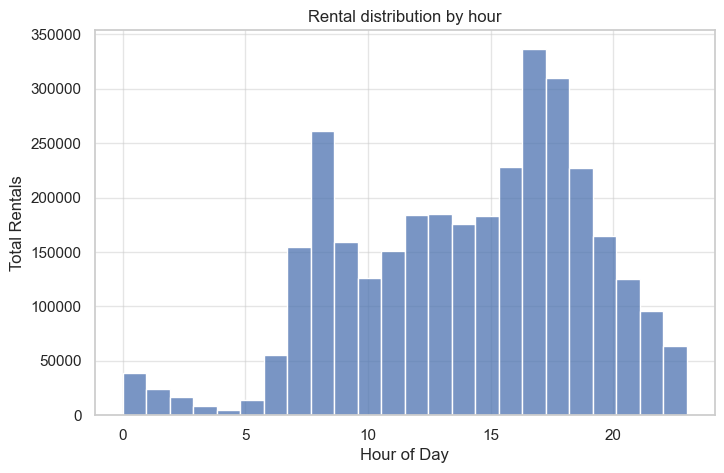

In [11]:
# Histogram: Rental distribution x hour
sns.set(style='whitegrid')

#Distribution of rentals by hour
plt.figure(figsize=(8,5))
sns.histplot(data=df_clean, x='hour', weights='rental_count', bins = 24, kde=False)
plt.title('Rental distribution by hour')
plt.xlabel('Hour of Day')
plt.ylabel('Total Rentals')
plt.show()

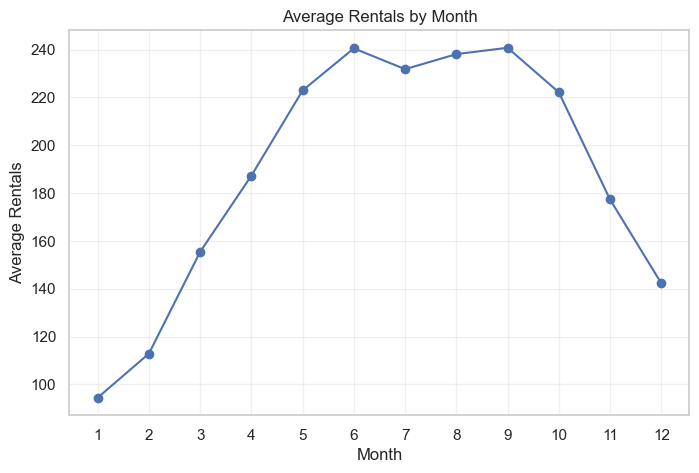

In [12]:
# Line plot: Month x Average Rental

monthly = (
    df_clean.groupby('month', as_index=False)['rental_count']
    .mean()
    .sort_values(by='month')
)

plt.figure(figsize=[8,5])
plt.plot(monthly['month'], monthly['rental_count'], marker= 'o')
plt.title('Average Rentals by Month')
plt.xlabel('Month')
plt.ylabel('Average Rentals')
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)
plt.show()

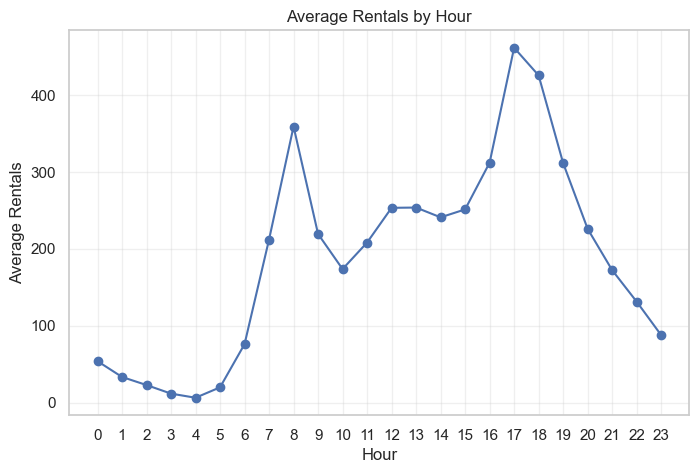

In [13]:
# Line plot: Month x Average Rental

hourly = (
    df_clean.groupby('hour', as_index=False)['rental_count']
    .mean()
    .sort_values(by='hour')
)

plt.figure(figsize=[8,5])
plt.plot(hourly['hour'], hourly['rental_count'], marker= 'o')
plt.title('Average Rentals by Hour')
plt.xlabel('Hour')
plt.ylabel('Average Rentals')
plt.xticks(range(24))
plt.grid(True, alpha=0.3)
plt.show()

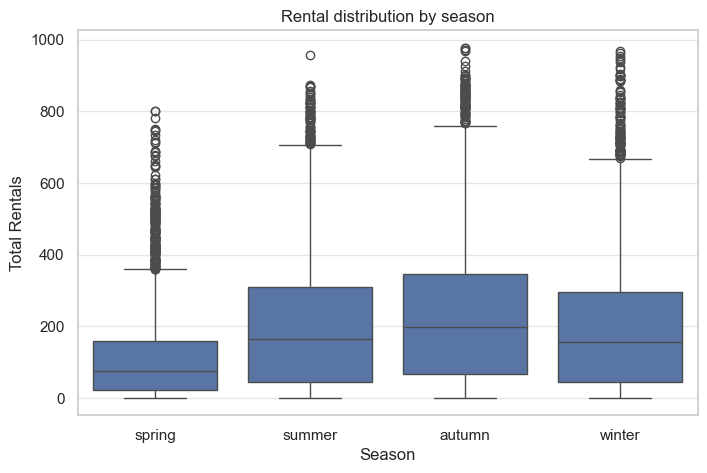

In [14]:
#Boxplot: Rentals x Season
plt.figure(figsize=[8,5])
sns.boxplot(data=df_clean, x='season', y='rental_count')
plt.title('Rental distribution by season')
plt.xlabel('Season')
plt.ylabel('Total Rentals')
plt.show()

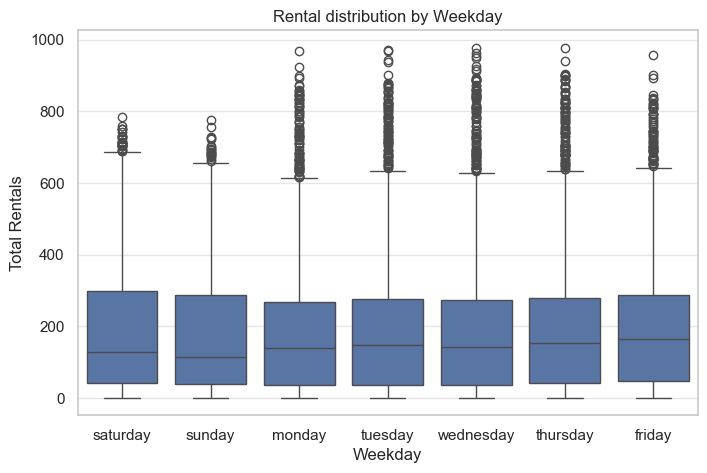

In [15]:
#Boxplot: Rentals x Weekday
plt.figure(figsize=[8,5])
sns.boxplot(data=df_clean, x='weekday', y='rental_count')
plt.title('Rental distribution by Weekday')
plt.xlabel('Weekday')
plt.ylabel('Total Rentals')
plt.show()

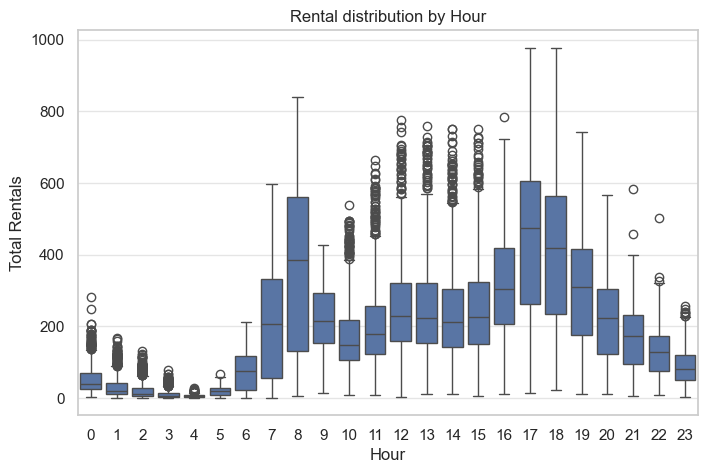

In [16]:
#Boxplot: Rentals x Hour
plt.figure(figsize=[8,5])
sns.boxplot(data=df_clean, x='hour', y='rental_count')
plt.title('Rental distribution by Hour')
plt.xlabel('Hour')
plt.ylabel('Total Rentals')
plt.show()

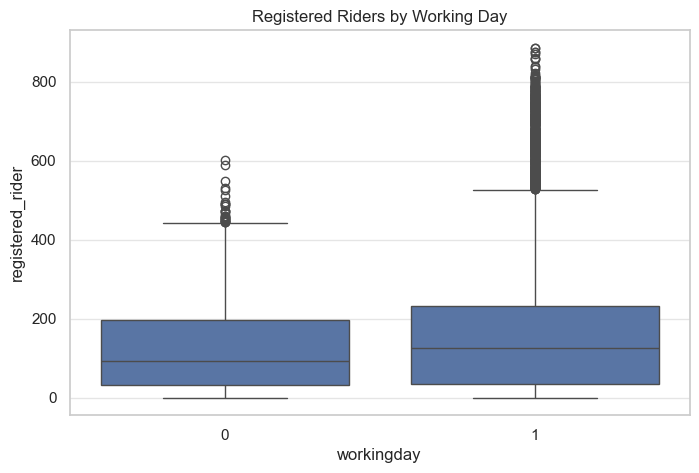

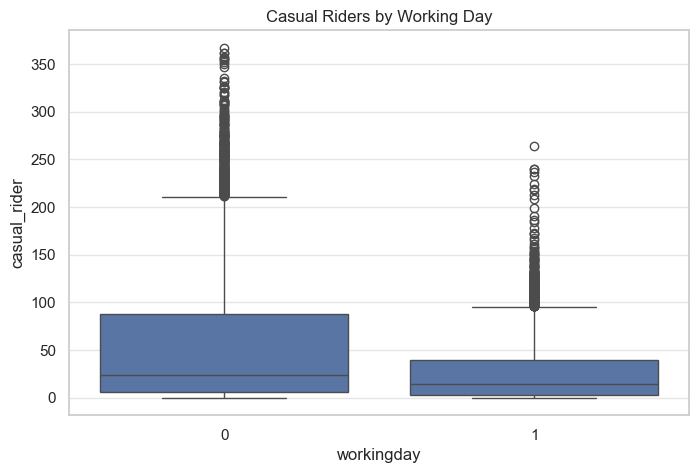

In [17]:
#Boxplot: Registered x Working Day
plt.figure(figsize=[8,5])
sns.boxplot(data=df_clean, x='workingday', y='registered_rider')
plt.title('Registered Riders by Working Day')
plt.show()

#Boxplot: Casual x Working Day
plt.figure(figsize=[8,5])
sns.boxplot(data=df_clean, x='workingday', y='casual_rider')
plt.title('Casual Riders by Working Day')
plt.show()

<Axes: xlabel='weather', ylabel='rental_count'>

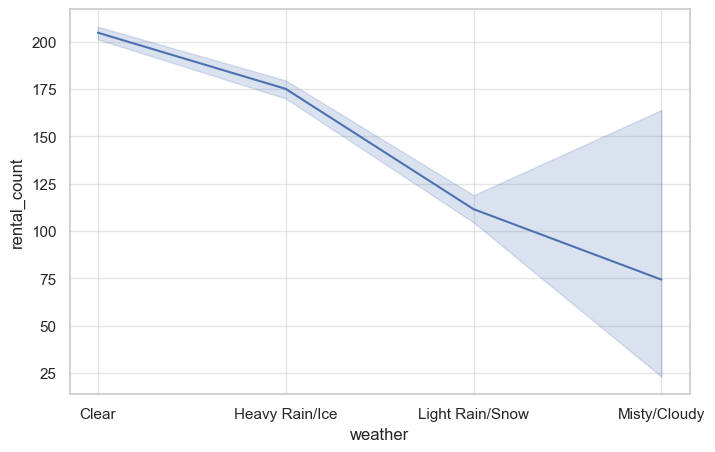

In [18]:
# Lineplot: Weather x Rental count
plt.figure(figsize=[8,5])
sns.lineplot(data=df_clean, x='weather', y='rental_count')

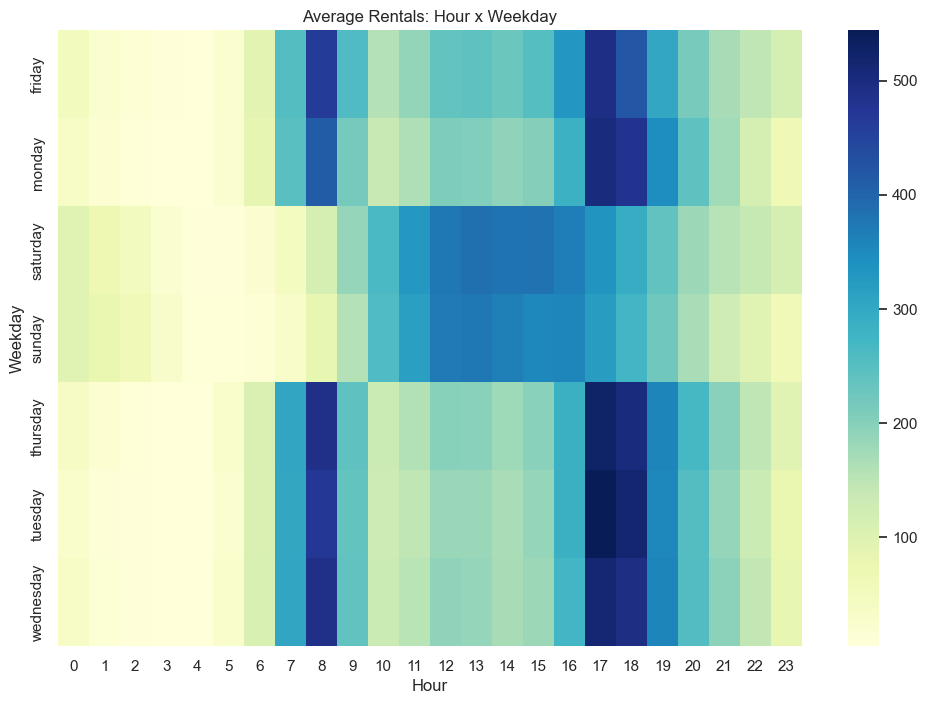

In [19]:
# Hour vs. Weekday heatmap
heat = df_clean.pivot_table(values='rental_count',index='weekday', columns='hour', aggfunc='mean')

plt.figure(figsize=(12,8))
sns.heatmap(heat, cmap='YlGnBu')
plt.title('Average Rentals: Hour x Weekday')
plt.xlabel('Hour')
plt.ylabel('Weekday')
plt.show()

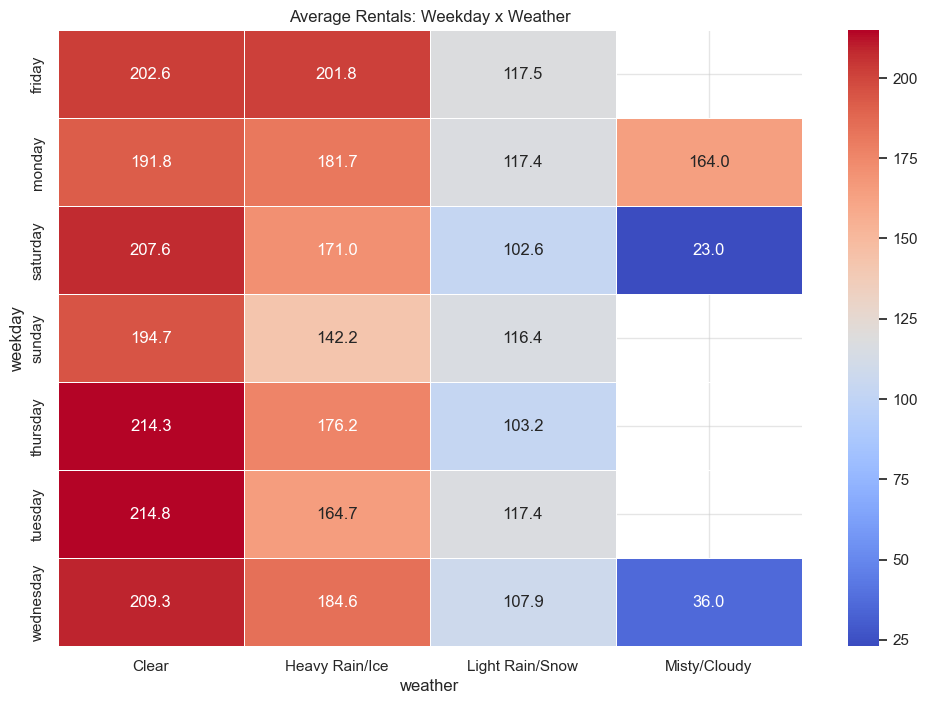

In [20]:
# Weekday x Weather
weather_season = df_clean.pivot_table(values='rental_count', index='weekday', columns='weather', aggfunc='mean')

plt.figure(figsize=(12, 8))
sns.heatmap(weather_season, annot=True, cmap='coolwarm', fmt='.1f', linewidths=.5)
plt.title('Average Rentals: Weekday x Weather')
plt.show()

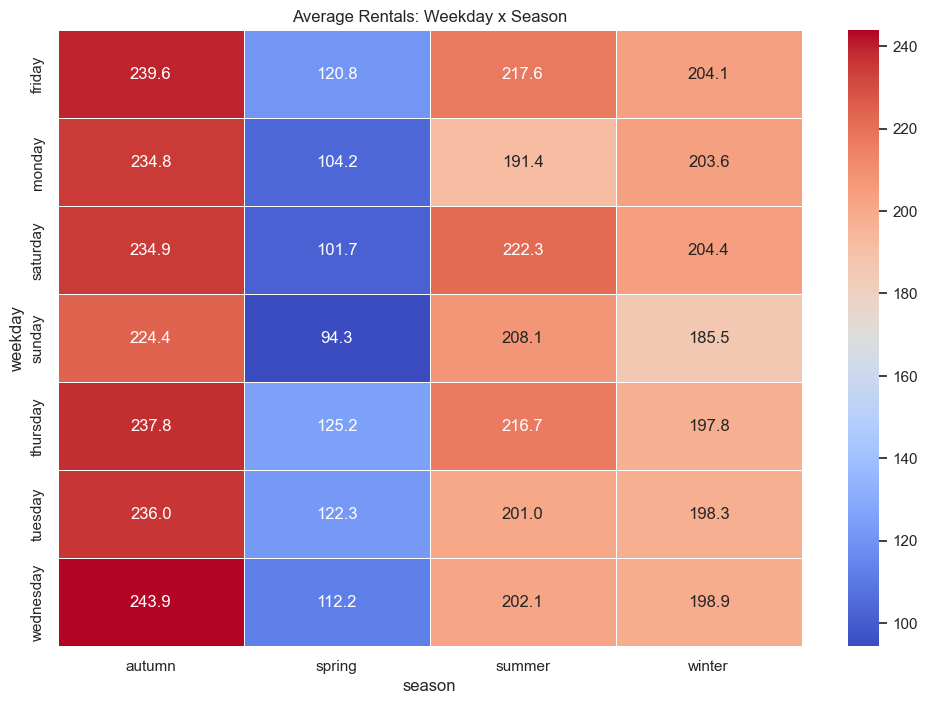

In [21]:
# Weekday x Season
weather_season = df_clean.pivot_table(values='rental_count',index='weekday', columns='season', aggfunc='mean')

plt.figure(figsize=(12,8))
sns.heatmap(weather_season, annot=True, cmap='coolwarm', fmt='.1f', linewidths=.5)
plt.title('Average Rentals: Weekday x Season')
plt.show()

In [22]:
# T-test to compare casual vs registered population
casual = df_clean['casual_rider']
registered = df_clean['registered_rider']

t_stat, p_val = ttest_ind(casual, registered, equal_var=False)

print('T-test: Casual vs Registered Riders')
print(f'T-Statistic: {t_stat:.4f}')
print(f'p-value: {p_val:.6f}')

T-test: Casual vs Registered Riders
T-Statistic: -97.8133
p-value: 0.000000


In [23]:
# Crosstab: Year in Weather
pd.crosstab(df_clean['year'], df_clean['weather'])

weather,Clear,Heavy Rain/Ice,Light Rain/Snow,Misty/Cloudy
year,,,,
2011,5645,2218,781,1
2012,5768,2326,638,2


In [24]:
# Snapshot of Ridership
print(df_clean[['casual_rider', 'registered_rider']].describe())

       casual_rider  registered_rider
count  17379.000000      17379.000000
mean      35.676218        153.786869
std       49.305030        151.357286
min        0.000000          0.000000
25%        4.000000         34.000000
50%       17.000000        115.000000
75%       48.000000        220.000000
max      367.000000        886.000000


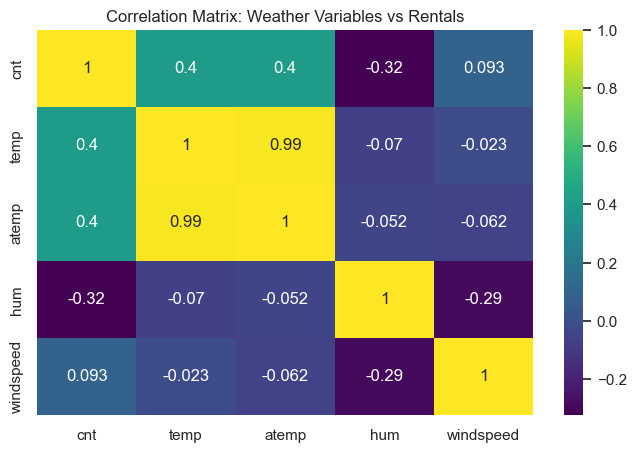

In [25]:
#Correlation Analysis: Weather, Temp, Humidity, WindSpeed

# Select numeric variables
corr_vars = ["cnt", "temp", "atemp", "hum", "windspeed"]

corr_matrix = df[corr_vars].corr()

plt.figure(figsize=(8,5))
sns.heatmap(corr_matrix, annot=True, cmap="viridis")
plt.title("Correlation Matrix: Weather Variables vs Rentals")
plt.show()

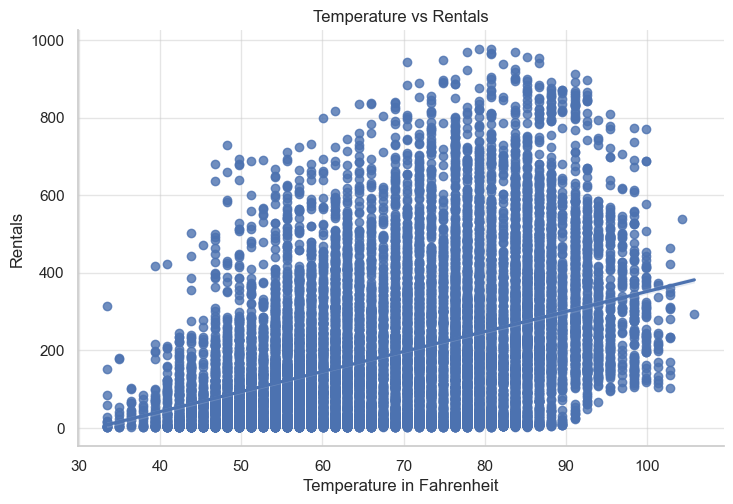

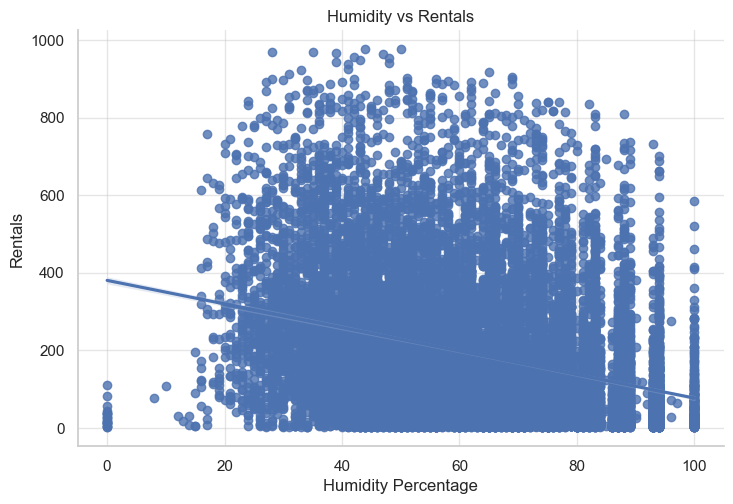

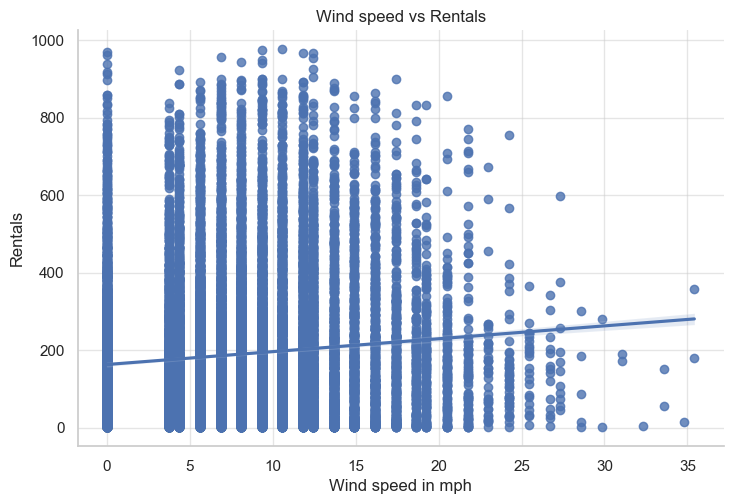

In [26]:
# Scatter plots with regression lines: Temperature, Humidity, Wind speed vs. Rentals
sns.lmplot(data=df_clean, x="temp", y="rental_count", height=5, aspect=1.5)
plt.title("Temperature vs Rentals")
plt.xlabel("Temperature in Fahrenheit")
plt.ylabel("Rentals")
plt.ylabel("Rentals")
plt.show()

sns.lmplot(data=df_clean, x='humidity', y="rental_count", height=5, aspect=1.5)
plt.title("Humidity vs Rentals")
plt.xlabel("Humidity Percentage")
plt.ylabel("Rentals")
plt.show()

sns.lmplot(data=df_clean, x="wind_speed", y="rental_count", height=5, aspect=1.5)
plt.title("Wind speed vs Rentals")
plt.xlabel("Wind speed in mph")
plt.ylabel("Rentals")
plt.show()

In [27]:
# ANOVA: Season x Rentals

model = ols("cnt ~ C(season)", data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

                 sum_sq       df           F         PR(>F)
C(season)  3.772936e+07      3.0  409.181037  7.401071e-257
Residual   5.340322e+08  17375.0         NaN            NaN


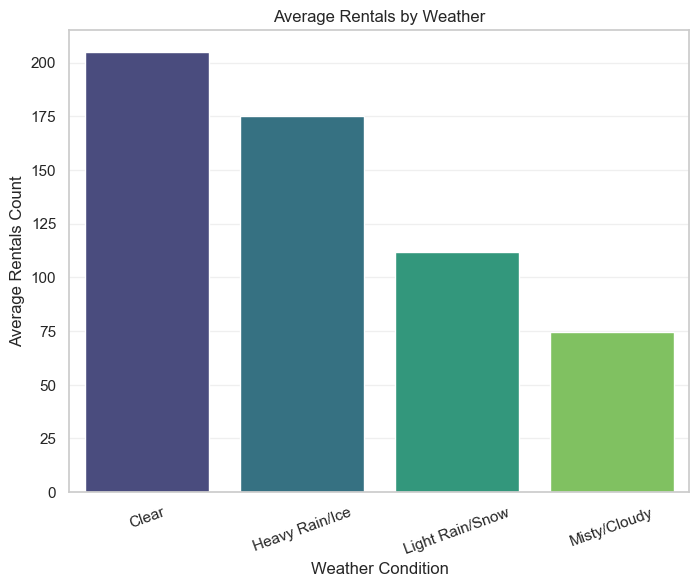

In [28]:
# Average rentals per weather category
weather_avg = (
    df_clean.groupby('weather', as_index=False)['rental_count']
    .mean()
    .sort_values(by='rental_count', ascending=False)
)

plt.figure(figsize=(8,6))
sns.barplot(data=weather_avg, x='weather', y='rental_count', hue='weather', palette='viridis', legend=False)
plt.title('Average Rentals by Weather')
plt.xlabel('Weather Condition')
plt.ylabel('Average Rentals Count')
plt.xticks(rotation=20)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [29]:
# Ordinary Least Squares Regression Results
X = df[['hr',"temp", "hum", "windspeed"]]
y = df["cnt"]

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.325
Model:                            OLS   Adj. R-squared:                  0.325
Method:                 Least Squares   F-statistic:                     2092.
Date:                Wed, 13 May 2026   Prob (F-statistic):               0.00
Time:                        18:55:36   Log-Likelihood:            -1.1163e+05
No. Observations:               17379   AIC:                         2.233e+05
Df Residuals:                   17374   BIC:                         2.233e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         69.3765      6.363     10.903      0.0

In [30]:
# OLS Regression Results
X = df[["temp", "hum", "windspeed"]]
y = df["cnt"]

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.251
Model:                            OLS   Adj. R-squared:                  0.251
Method:                 Least Squares   F-statistic:                     1945.
Date:                Wed, 13 May 2026   Prob (F-statistic):               0.00
Time:                        18:55:36   Log-Likelihood:            -1.1253e+05
No. Observations:               17379   AIC:                         2.251e+05
Df Residuals:                   17375   BIC:                         2.251e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        175.8100      6.187     28.416      0.0

In [31]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=df_clean["rental_count"], groups=df_clean["season"], alpha=0.05)
print(tukey)


   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj    lower     upper   reject
---------------------------------------------------------
autumn spring -124.9017    0.0 -134.5431 -115.2603   True
autumn summer  -27.6722    0.0  -37.2192  -18.1252   True
autumn winter  -37.1474    0.0  -46.7946  -27.5001   True
spring summer   97.2295    0.0    87.542   106.917   True
spring winter   87.7543    0.0    77.968   97.5406   True
summer winter   -9.4752 0.0582  -19.1685    0.2181  False
---------------------------------------------------------


In [32]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=df_clean["rental_count"], groups=df_clean["weather"], alpha=0.05)
print(tukey)


           Multiple Comparison of Means - Tukey HSD, FWER=0.05            
     group1          group2      meandiff p-adj    lower    upper   reject
--------------------------------------------------------------------------
          Clear  Heavy Rain/Ice  -29.7038    0.0  -37.7909 -21.6166   True
          Clear Light Rain/Snow    -93.29    0.0 -106.2676 -80.3123   True
          Clear    Misty/Cloudy -130.5359 0.5886 -396.7534 135.6815  False
 Heavy Rain/Ice Light Rain/Snow  -63.5862    0.0  -77.6067 -49.5658   True
 Heavy Rain/Ice    Misty/Cloudy -100.8322 0.7649 -367.1025 165.4381  False
Light Rain/Snow    Misty/Cloudy  -37.2459 0.9841 -303.7096 229.2177  False
--------------------------------------------------------------------------


In [33]:
# Load the csv for Prophet Model
df_clean = pd.read_csv('data/day.csv', parse_dates=["dteday"])
df_clean = df.sort_values("dteday")
df_clean.head().T

,0,23,22,21,20
instant,1,24,23,22,21
dteday,2011-01-01,2011-01-01,2011-01-01,2011-01-01,2011-01-01
season,1,1,1,1,1
yr,0,0,0,0,0
mnth,1,1,1,1,1
hr,0,23,22,21,20
holiday,0,0,0,0,0
weekday,6,6,6,6,6
workingday,0,0,0,0,0
weathersit,1,2,2,2,2


In [34]:
# Create dataframe for Prophet, rename requirement columns to ds, y respectively.
df_daily = df.groupby('dteday', as_index=False)['cnt'].sum()
df_daily = df_daily.rename(columns={'dteday': 'ds', 'cnt': 'y'})

In [35]:
# Review output
df_daily.head()

,ds,y
0,2011-01-01,985
1,2011-01-02,801
2,2011-01-03,1349
3,2011-01-04,1562
4,2011-01-05,1600


In [36]:
# Fit the prophet model
m = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
m.fit(df_daily)

18:55:37 - cmdstanpy - INFO - Chain [1] start processing
18:55:37 - cmdstanpy - INFO - Chain [1] done processing


In [37]:
# Generate 12-month forecast
future = m.make_future_dataframe(periods=365)
forecast = m.predict(future)

In [38]:
# Tail inspection of forecast output prior to export
forecast[['ds','yhat','yhat_lower','yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
1091,2013-12-27,5624.714546,4476.358101,6937.391038
1092,2013-12-28,5542.149135,4284.364561,6793.175234
1093,2013-12-29,5245.487302,4039.330778,6488.748280
1094,2013-12-30,5391.768782,4075.394964,6607.368361
1095,2013-12-31,5607.949840,4324.675807,6819.548550


In [39]:
# Export forecast back to csv file
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_csv("forecast_output.csv", index=False)